# Curso: Redes Neurais para Processamento de Linguagem Natural

Prof. [Denilson Alves Pereira](https://sites.google.com/ufla.br/denilsonpereira) <br>
Departamento de Ciência da Computação (DCC) <br>
Instituto de Ciências Exatas e Tecnológicas (ICET) <br> 
Universidade Federal de Lavras (UFLA)

## Classificação de Texto usando uma Rede Neural Recorrente (RNN)

Objetivo: apresentar um exemplo de uso de uma Rede Neural Recorrente para classificação de texto.

Você vai aprender a:
- Usar as bibliotecas de Redes Neurais Recorrentes
- Configurar uma arquitetura usando camadas LSTM biderecionais
- Treinar um modelo de PLN para classificação de sentimentos
- Avaliar o modelo treinado

Referências: <br>
O código do exemplo foi obtido de: <br>
https://www.tensorflow.org/text/tutorials/text_classification_rnn <br>
Documentação da API Keras para Camadas Recorrentes:<br>
https://keras.io/api/layers/recurrent_layers/<br>
https://www.tensorflow.org/guide/keras/working_with_rnns<br>

Versão: Fevereiro, 2024

### Pacotes

In [2]:
# Instala bibliotecas, se necessário
# %pip install --force-reinstall \
#     "tensorflow==2.14.0" \
#     "tensorflow-datasets==4.9.4" \
#     "tensorflow-metadata==1.14.0" \
#     "protobuf==3.20.3"

In [3]:
import numpy as np
import tensorflow_datasets as tfds
import tensorflow as tf
import matplotlib.pyplot as plt

tfds.disable_progress_bar()

### Função para plotar gráficos

In [4]:
def plot_graphs(history, metric):
  plt.plot(history.history[metric])
  plt.plot(history.history['val_'+metric], '')
  plt.xlabel("Epochs")
  plt.ylabel(metric)
  plt.legend([metric, 'val_'+metric])

### Dataset

IMDB - dataset de revisão de filmes, rotulado para classificação binária: sentimento positivo ou negativo.

In [5]:
dataset, info = tfds.load('imdb_reviews', with_info=True, as_supervised=True)
train_dataset, test_dataset = dataset['train'], dataset['test']

train_dataset.element_spec

2026-09-17 17:07:15.467004: W tensorflow/tsl/platform/cloud/google_auth_provider.cc:184] All attempts to get a Google authentication bearer token failed, returning an empty token. Retrieving token from files failed with "NOT_FOUND: Could not locate the credentials file.". Retrieving token from GCE failed with "FAILED_PRECONDITION: Error executing an HTTP request: libcurl code 6 meaning 'Couldn't resolve host name', error details: Could not resolve host: metadata.google.internal".


Dataset imdb_reviews downloaded and prepared to /home/marcos/tensorflow_datasets/imdb_reviews/plain_text/1.0.0. Subsequent calls will reuse this data.


2026-09-17 17:08:32.583765: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:894] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-09-17 17:08:32.585300: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2211] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


(TensorSpec(shape=(), dtype=tf.string, name=None),
 TensorSpec(shape=(), dtype=tf.int64, name=None))

In [6]:
# Retorna uma amostra do dataset de treino. Par: texto, rótulo
for example, label in train_dataset.take(1):
  print('text: ', example.numpy())
  print('label: ', label.numpy())

text:  b"This was an absolutely terrible movie. Don't be lured in by Christopher Walken or Michael Ironside. Both are great actors, but this must simply be their worst role in history. Even their great acting could not redeem this movie's ridiculous storyline. This movie is an early nineties US propaganda piece. The most pathetic scenes were those when the Columbian rebels were making their cases for revolutions. Maria Conchita Alonso appeared phony, and her pseudo-love affair with Walken was nothing but a pathetic emotional plug in a movie that was devoid of any real meaning. I am disappointed that there are movies like this, ruining actor's like Christopher Walken's good name. I could barely sit through it."
label:  0


2026-09-17 17:08:32.731740: W tensorflow/core/kernels/data/cache_dataset_ops.cc:854] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.


Embaralha os dados de treinamento <br>
Cria batches (lotes) para os pares texto, rótulo

In [7]:
BUFFER_SIZE = 10000
BATCH_SIZE = 64

In [8]:
train_dataset = train_dataset.shuffle(BUFFER_SIZE).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
test_dataset = test_dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

In [9]:
for example, label in train_dataset.take(1):
  print('texts: ', example.numpy()[:3])
  print()
  print('labels: ', label.numpy()[:3])

texts:  [b"It may have not been up for academy awards and admittedly, it's pretty cheesy, but it's just so much fun! Nothing makes me smile like Bill and Ted. Lovable, optimistic, and hilarious, Bill and Ted are a great way to unwind.<br /><br />Although I love Excellent Adventure, Bogus Journey is funnier to me. Death is flippin hilarious and Bill and Ted are even more endearing. People give me grief about loving this movie, but only really pretentious movie-watchers will say it's not even a bit entertaining. If you like this, you'll probably also be a fan of Wayne's World, Dude Where's My Car, and Dumb and Dumber. Admit it, though foolish, they make you grin and turn your tickle box over. So watch them just for kicks and giggles!!"
 b'If you have beloved actors, Peter Falk, Rip Torn, George Segal, and Bill Cobbs, you don\'t need Billy Burke, Coolio, or any other distractions. Massive talent is totally wasted in "Three Days to Vegas", with the blame falling squarely on the script. My 

2026-09-17 17:08:32.871182: W tensorflow/core/kernels/data/cache_dataset_ops.cc:854] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.


### Codificação (Encoder) do Texto

O texto bruto carregado pelo tfds necessita ser processado antes que ele possa ser usado em um modelo. A forma mais simples de processar o texto para treinamento é usar a camada *TextVectorization*. Essa camada tem muitas capacidades, mas aqui usaremos o seu comportamento padrão.

Cria a camada e passa o texto do dataset para seu método *.adapt*.

In [10]:
VOCAB_SIZE = 1000
encoder = tf.keras.layers.TextVectorization(max_tokens=VOCAB_SIZE)
encoder.adapt(train_dataset.map(lambda text, label: text))

O método *.adapt* define o vocabulário da camada.<br>
Listamos abaixo os primeiros 20 tokens, ordenados por frequência, exceto os dois primeiros, que são o token de preenchimento (*padding*) e token desconhecido (*unknown*)

In [11]:
vocab = np.array(encoder.get_vocabulary())
vocab[:20]

array(['', '[UNK]', 'the', 'and', 'a', 'of', 'to', 'is', 'in', 'it', 'i',
       'this', 'that', 'br', 'was', 'as', 'for', 'with', 'movie', 'but'],
      dtype='<U14')

Uma vez que o vocabulário é definido, a camada pode codificar o texto em índices. Os tensores de índices são preenchidos com zeros (*0-padded*) para a sequência mais longa no batch (a menos que você defina um valor fixo para *output_sequence_length*.

In [12]:
encoded_example = encoder(example)[:3].numpy()
encoded_example

array([[  9, 194,  26, ...,   0,   0,   0],
       [ 45,  23,  26, ...,   0,   0,   0],
       [230,   1, 838, ...,   0,   0,   0]])

Com a configuração padrão, o processo não é completamente reversível. As principais razões são:
- O valor padrão para *preprocessing.TextVectorization* é "lower_and_strip_punctuation".
- O tamanho limitado do vocabulário e a falta de alternativa baseada em caracteres resultam em alguns tokens desconhecidos.

In [13]:
for n in range(3):
  print("Original: ", example[n].numpy())
  print("Round-trip: ", " ".join(vocab[encoded_example[n]]))
  print()

Original:  b"It may have not been up for academy awards and admittedly, it's pretty cheesy, but it's just so much fun! Nothing makes me smile like Bill and Ted. Lovable, optimistic, and hilarious, Bill and Ted are a great way to unwind.<br /><br />Although I love Excellent Adventure, Bogus Journey is funnier to me. Death is flippin hilarious and Bill and Ted are even more endearing. People give me grief about loving this movie, but only really pretentious movie-watchers will say it's not even a bit entertaining. If you like this, you'll probably also be a fan of Wayne's World, Dude Where's My Car, and Dumb and Dumber. Admit it, though foolish, they make you grin and turn your tickle box over. So watch them just for kicks and giggles!!"
Round-trip:  it may have not been up for [UNK] [UNK] and [UNK] its pretty cheesy but its just so much fun nothing makes me [UNK] like bill and [UNK] [UNK] [UNK] and hilarious bill and [UNK] are a great way to [UNK] br although i love excellent [UNK] [UNK

### Modelo de Classificação

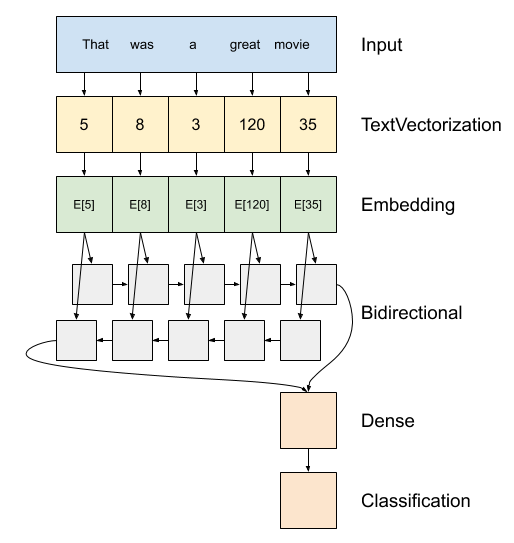

1. O modelo pode ser criado como um *tf.keras.Sequential*.
2. A primeira camada é o *encoder*, que converte o texto para uma sequência de índices de tokens.
3. Depois do *encoder* está a camada de *embedding*. Uma cada de *embedding* armazena um vetor por palavra. Quando chamada, ela converte as sequências de índices de palavras em sequências de vetores. Esses vetores são treináveis. Depois de treinados (com dados suficientes), palavras com significados similares frequentemente têm vetores similares. Esse esquema é mais eficiente do que a operação equivalente de se criar um vetor *one-hot encoded* por meio da camada *tf.keras.layers.Dense*.
4. A Rede Neural Recorrente (RNN) processa uma sequência de entrada por meio da iteração dos elementos. RNNs passam a saída de um passo de tempo (*timestep*) para sua entrada no próximo *timestep*. O *wrapper* *tf.keras.layers.Bidirectional* também pode ser usado com uma camada RNN. Isso propaga a entrada para frente e para trás na camada RNN e então concatena a saída final. Nós usamos aqui uma camada LSTM (Long Short-Term Memory).
   - A principal vantagem de uma RNN bidirecional é que o sinal desde o início da entrada não necessita ser processado em cada intervalo de tempo para afetar a saída.
   - A principal desvantagem de uma RNN bidirecional é que você não pode transmitir previsões com eficiência à medida que palavras são adicionadas ao final.
6. Depois que a RNN converte a sequência em um único vetor, as duas camadas densas fazem algum processamento final e convertem essa representação vetorial em um único logit como saída da classificação.

In [14]:
model = tf.keras.Sequential([
    encoder,
    tf.keras.layers.Embedding(
        input_dim=len(encoder.get_vocabulary()),
        output_dim=64,
        # Use masking to handle the variable sequence lengths
        mask_zero=True),
    tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(64)),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(1)
])

Compila o modelo Keras para configurar o processo de treinamento

In [15]:
model.compile(loss=tf.keras.losses.BinaryCrossentropy(from_logits=True),
              optimizer=tf.keras.optimizers.Adam(1e-4),
              metrics=['accuracy'])

### Treinamento do Modelo

In [16]:
history = model.fit(train_dataset, epochs=10,
                    validation_data=test_dataset,
                    validation_steps=30)

Epoch 1/10


391/391 [==============================] - 86s 211ms/step - loss: 0.6303 - accuracy: 0.5824 - val_loss: 0.4812 - val_accuracy: 0.8005
Epoch 2/10


2026-09-17 17:10:01.156248: W tensorflow/core/kernels/data/cache_dataset_ops.cc:854] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.


391/391 [==============================] - 101s 259ms/step - loss: 0.4397 - accuracy: 0.7934 - val_loss: 0.3926 - val_accuracy: 0.8240
Epoch 3/10


2026-09-17 17:11:42.303949: W tensorflow/core/kernels/data/cache_dataset_ops.cc:854] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.


...

2026-09-17 17:22:22.463177: W tensorflow/core/kernels/data/cache_dataset_ops.cc:854] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.


391/391 [==============================] - 107s 274ms/step - loss: 0.3057 - accuracy: 0.8703 - val_loss: 0.3243 - val_accuracy: 0.8589
Epoch 10/10


2026-09-17 17:24:09.480924: W tensorflow/core/kernels/data/cache_dataset_ops.cc:854] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.


391/391 [==============================] - 106s 271ms/step - loss: 0.3036 - accuracy: 0.8712 - val_loss: 0.3270 - val_accuracy: 0.8453


2026-09-17 17:25:55.365149: W tensorflow/core/kernels/data/cache_dataset_ops.cc:854] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.


### Avaliação do Modelo no Conjunto de Dados de Teste

In [17]:
test_loss, test_acc = model.evaluate(test_dataset)

print('Test Loss:', test_loss)
print('Test Accuracy:', test_acc)

391/391 [==============================] - 37s 94ms/step - loss: 0.3277 - accuracy: 0.8460
Test Loss: 0.3276515305042267
Test Accuracy: 0.8460000157356262


Plota gráficos de acurácia e perda

(0.0, 0.6466535270214081)

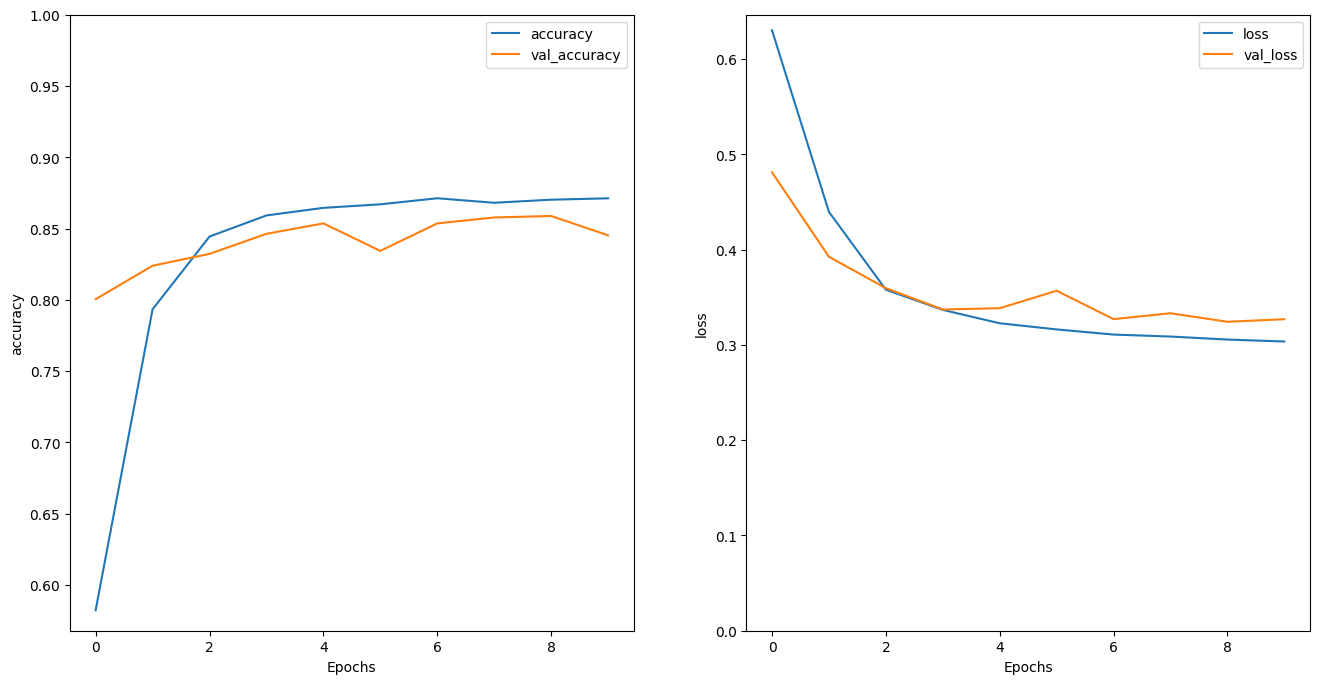

In [18]:
plt.figure(figsize=(16, 8))
plt.subplot(1, 2, 1)
plot_graphs(history, 'accuracy')
plt.ylim(None, 1)
plt.subplot(1, 2, 2)
plot_graphs(history, 'loss')
plt.ylim(0, None)

### Predição de uma Nova Sentença

Se a predição for >= 0.0, então ela é positiva, caso contrário, ela é negativa

In [19]:
sample_text = ('The movie was cool. The animation and the graphics '
               'were out of this world. I would recommend this movie.')
predictions = model.predict(np.array([sample_text]))
print(predictions)

1/1 [==============================] - 2s 2s/step
[[1.0123516]]


### Pilha de Camadas LSTM

Em uma arquitetura de Redes Neurais Recorrentes, várias camadas podem ser empilhadas para produzir o resultado final. Nesse caso, a saída de cada *timestep* é conectada na entrada do *timestep* da camada acima.

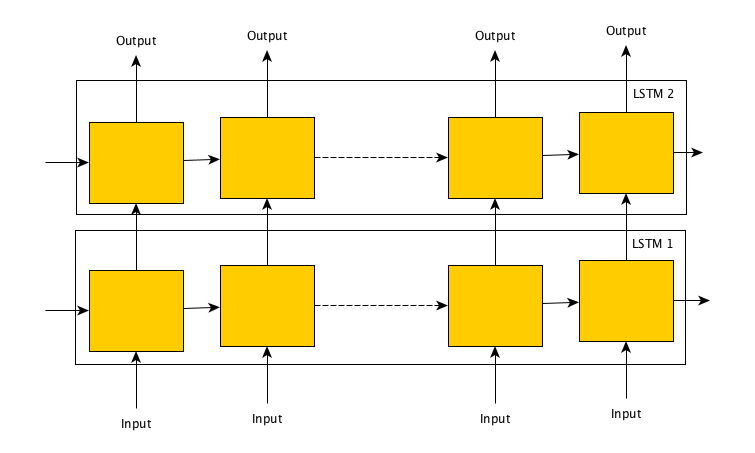

As camadas recorrentes Keras têm dois modos disponíveis que são controlados pelo argumento *return_sequences*:
- Se False, ele retorna somente a última saída para cada sequência de entrada (um tensor 2D na forma *(batch_size, output_features)*). Esse é o modo padrão, usado no modelo anterior.
- Se True, a sequência completa de saídas sucessivas para cada *timestep* é retornada (um tensor 3D na forma *(batch_size, timesteps, output_features)*).

O fluxo de informação para uma camada com *return_sequences=True* se parece com o desenho abaixo:

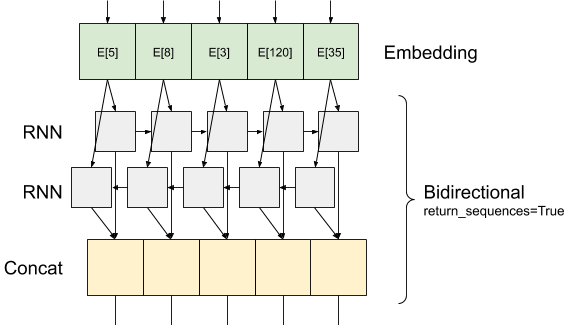

In [20]:
model = tf.keras.Sequential([
    encoder,
    tf.keras.layers.Embedding(len(encoder.get_vocabulary()), 64, mask_zero=True),
    tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(64,  return_sequences=True)),
    tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(32)),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(1)
])

In [21]:
model.compile(loss=tf.keras.losses.BinaryCrossentropy(from_logits=True),
              optimizer=tf.keras.optimizers.Adam(1e-4),
              metrics=['accuracy'])

In [22]:
history = model.fit(train_dataset, epochs=10,
                    validation_data=test_dataset,
                    validation_steps=30)

Epoch 1/10
391/391 [==============================] - 222s 545ms/step - loss: 0.6090 - accuracy: 0.6054 - val_loss: 0.4057 - val_accuracy: 0.8057
Epoch 2/10
391/391 [==============================] - 205s 525ms/step - loss: 0.3745 - accuracy: 0.8348 - val_loss: 0.3495 - val_accuracy: 0.8344
Epoch 3/10
391/391 [==============================] - 213s 545ms/step - loss: 0.3340 - accuracy: 0.8555 - val_loss: 0.3273 - val_accuracy: 0.8443
Epoch 4/10
391/391 [==============================] - 214s 546ms/step - loss: 0.3192 - accuracy: 0.8624 - val_loss: 0.3220 - val_accuracy: 0.8578
Epoch 5/10
391/391 [==============================] - 212s 541ms/step - loss: 0.3146 - accuracy: 0.8640 - val_loss: 0.3173 - val_accuracy: 0.8552
Epoch 6/10
391/391 [==============================] - 211s 540ms/step - loss: 0.3085 - accuracy: 0.8687 - val_loss: 0.3502 - val_accuracy: 0.8609
Epoch 7/10
391/391 [==============================] - 211s 540ms/step - loss: 0.3071 - accuracy: 0.8674 - val_loss: 0.3226 -

In [23]:
test_loss, test_acc = model.evaluate(test_dataset)

print('Test Loss:', test_loss)
print('Test Accuracy:', test_acc)

391/391 [==============================] - 67s 170ms/step - loss: 0.3151 - accuracy: 0.8630
Test Loss: 0.31511175632476807
Test Accuracy: 0.8629599809646606


In [24]:
# predict on a sample text without padding.

sample_text = ('The movie was not good. The animation and the graphics '
               'were terrible. I would not recommend this movie.')
predictions = model.predict(np.array([sample_text]))
print(predictions)

1/1 [==============================] - 3s 3s/step
[[-1.9635482]]


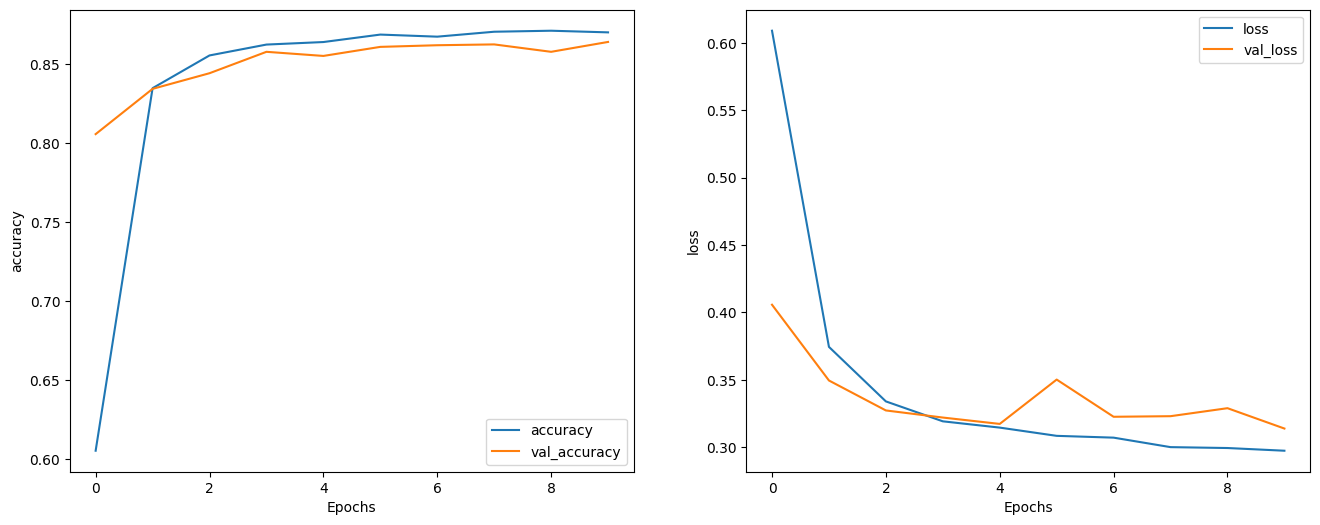

In [25]:
plt.figure(figsize=(16, 6))
plt.subplot(1, 2, 1)
plot_graphs(history, 'accuracy')
plt.subplot(1, 2, 2)
plot_graphs(history, 'loss')

# Fim

Esse notebook apresentou um exemplo de uso de uma Rede Neural Recorrente para classificação de texto. Você aprendeu a usar as bibliotecas de Redes Neurais Recorrentes, configurar uma arquitetura usando camadas LSTM biderecionais, treinar um modelo de PLN para classificação de sentimentos, avaliar o modelo treinado e predizer novas sentenças de entrada.

-------------------------------------------